<a href="https://colab.research.google.com/github/LohithKarri/Large-Language-models/blob/main/23040177_code_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A research log: can DistilBERT hear the quiet classes in an angry airline-tweet corpus?

**Research Methods (7PAM2015), Large Language Models · Individual project (25%)**

### **Pinning the bench before I touch anything**

In [ ]:
# Colab install. Pinned for a repeatable run; safe to comment out if the runtime already has them.
!pip -q install "transformers>=4.40,<5" "datasets>=2.19" "scikit-learn>=1.3" "matplotlib>=3.7" "seaborn>=0.13" "accelerate>=0.30" "kagglehub>=0.3" 2>/dev/null
print("install step complete")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 127.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 50.5 MB/s eta 0:00:00
install step complete


In [ ]:
from __future__ import annotations

import json
import os
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch

# --- one seed, pinned across every source I can reach ---
RUN_SEED = 461


def lock_seeds(seed: int) -> None:
    """Freeze Python, NumPy and torch (CPU + CUDA) so the split and the weights are reproducible."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True   # deterministic GPU kernels, at a small speed cost
    torch.backends.cudnn.benchmark = False


lock_seeds(RUN_SEED)

# Prefer the Colab GPU, but never hard-fail on a CPU-only box.
compute = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch", torch.__version__, "| running on:", compute)

torch 2.11.0+cu128 | running on: cuda


In [ ]:
def scorecard(title: str, values: dict) -> None:
    """Print an aligned key:value 'report card' instead of a bare table (my house style here)."""
    width = 46
    print("+" + "-" * width + "+")
    print("| " + title.ljust(width - 1) + "|")
    print("+" + "-" * width + "+")
    for key, val in values.items():
        shown = f"{val:.4f}" if isinstance(val, float) else str(val)
        print("| " + f"{key:<24}{shown:>{width - 25}}" + " |")
    print("+" + "-" * width + "+")


# Relative output tree only: nothing absolute, so the log is portable.
WORK = Path("outputs")
FIGURES = WORK / "figures"
TABLES = WORK / "tables"
CHECKPOINTS = WORK / "models"
for _d in (FIGURES, TABLES, CHECKPOINTS):
    _d.mkdir(parents=True, exist_ok=True)
print("output tree ready under:", WORK)

output tree ready under: outputs


### **Deciding the settings up front, in one visible place**

In [ ]:
# Label order is fixed so class ids never drift: negative=0, neutral=1, positive=2.
LABELS = ("negative", "neutral", "positive")
ID_OF = {name: i for i, name in enumerate(LABELS)}
NAME_OF = {i: name for name, i in ID_OF.items()}
N_CLASSES = len(LABELS)

CFG = {
    # data handles
    "kaggle_slug": "crowdflower/twitter-airline-sentiment",
    "csv_name": "Tweets.csv",
    "text_col": "text",
    "label_col": "airline_sentiment",
    # split
    "test_fraction": 0.15,   # held out, read exactly once
    "val_fraction": 0.15,    # carved from the train pool for model selection
    "sample_rows": None,     # None = full data
    # model / tokeniser
    "checkpoint": "distilbert-base-uncased",
    "max_length": 96,        # revisited empirically in Entry 6
    # optimisation
    "batch_size": 32,        # tweets are short, so a wide batch fits
    "learning_rate": 2e-5,
    "epochs": 3,
    "weight_decay": 0.01,
    "warmup_ratio": 0.1,
    "class_weighted": True,  # the design choice I stress-test in Entry 11
    "averaging": "macro",    # every class counts equally under the skew
}
scorecard("Entry 1, run configuration", {
    "checkpoint": CFG["checkpoint"],
    "max_length": CFG["max_length"],
    "batch_size": CFG["batch_size"],
    "epochs": CFG["epochs"],
    "averaging": CFG["averaging"],
    "seed": RUN_SEED,
})

+----------------------------------------------+
| Entry 1, run configuration                   |
+----------------------------------------------+
| checkpoint              distilbert-base-uncased |
| max_length                                 96 |
| batch_size                                 32 |
| epochs                                      3 |
| averaging                               macro |
| seed                                      461 |
+----------------------------------------------+


### **Pulling the tweets down from Kaggle**

In [ ]:
import kagglehub

cache_dir = kagglehub.dataset_download(CFG["kaggle_slug"])
csv_file = os.path.join(cache_dir, CFG["csv_name"])
print("archive cached at:", cache_dir)

frame_raw = pd.read_csv(csv_file)
tweets = (
    frame_raw[[CFG["text_col"], CFG["label_col"]]]
    .rename(columns={CFG["text_col"]: "message", CFG["label_col"]: "sentiment"})
    .copy()
)
tweets["target"] = tweets["sentiment"].map(ID_OF)
scorecard("Entry 2, loaded", {"rows_raw": len(frame_raw), "columns_kept": "message, sentiment, target"})
print(tweets.head(3).to_string(index=False))

100%|██████████| 2.55M/2.55M [00:01<00:00, 1.93MB/s]

Extracting files...


archive cached at: /root/.cache/kagglehub/datasets/crowdflower/twitter-airline-sentiment/versions/4
+----------------------------------------------+
| Entry 2, loaded                              |
+----------------------------------------------+
| rows_raw                                14640 |
| columns_kept            message, sentiment, target |
+----------------------------------------------+
                                                                 message sentiment  target
                                     @VirginAmerica What @dhepburn said.   neutral       1
@VirginAmerica plus you've added commercials to the experience... tacky.  positive       2
 @VirginAmerica I didn't today... Must mean I need to take another trip!   neutral       1


### **A quick sanity pass on the raw text and labels**

In [ ]:
missing_text = int(tweets["message"].isna().sum())
unmapped = int(tweets["target"].isna().sum())
dupes = int(tweets["message"].duplicated().sum())
scorecard("Entry 3, raw quality check", {
    "rows": len(tweets),
    "missing_text": missing_text,
    "unmapped_labels": unmapped,
    "exact_duplicate_text": dupes,
    "distinct_sentiments": ", ".join(sorted(tweets["sentiment"].dropna().unique())),
})

+----------------------------------------------+
| Entry 3, raw quality check                   |
+----------------------------------------------+
| rows                                    14640 |
| missing_text                                0 |
| unmapped_labels                             0 |
| exact_duplicate_text                      213 |
| distinct_sentiments     negative, neutral, positive |
+----------------------------------------------+


In [ ]:
kept_before = len(tweets)
tweets = tweets.dropna(subset=["message", "target"]).copy()
tweets["target"] = tweets["target"].astype(int)
tweets = tweets.drop_duplicates(subset="message").reset_index(drop=True)
scorecard("Entry 3, after cleaning", {"kept": len(tweets), "removed": kept_before - len(tweets)})

+----------------------------------------------+
| Entry 3, after cleaning                      |
+----------------------------------------------+
| kept                                    14427 |
| removed                                   213 |
+----------------------------------------------+


### **Measuring how lopsided the sentiment split really is**

/tmp/ipykernel_1115/967468410.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=balance.values, y=list(LABELS), orient="h",


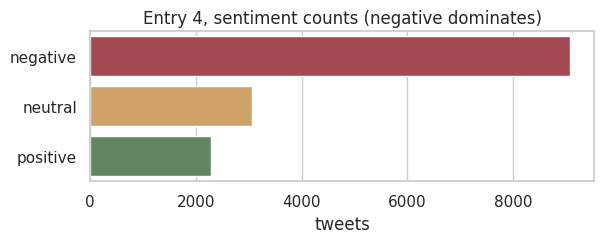

+----------------------------------------------+
| Entry 4, class balance                       |
+----------------------------------------------+
| negative                                 9080 |
| neutral                                  3057 |
| positive                                 2290 |
| negative_share                         0.6294 |
+----------------------------------------------+


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

balance = tweets["sentiment"].value_counts().reindex(LABELS)
neg_share = balance["negative"] / balance.sum()

plt.figure(figsize=(6.2, 2.6))
sns.barplot(x=balance.values, y=list(LABELS), orient="h",
            palette=["#b23a48", "#e0a458", "#5b8c5a"])
plt.title("Entry 4, sentiment counts (negative dominates)")
plt.xlabel("tweets")
plt.tight_layout()
plt.savefig(FIGURES / "entry4_balance.png", dpi=200, bbox_inches="tight")
plt.show()

scorecard("Entry 4, class balance", {
    "negative": int(balance["negative"]),
    "neutral": int(balance["neutral"]),
    "positive": int(balance["positive"]),
    "negative_share": float(neg_share),
})

### **Carving stratified train / validation / test slices**

In [ ]:
from sklearn.model_selection import train_test_split


def maybe_subsample(df: pd.DataFrame, n, seed: int) -> pd.DataFrame:
    """Stratified shrink for smoke tests; a no-op when sample_rows is None."""
    if n is None or n >= len(df):
        return df
    keep, _ = train_test_split(df, train_size=n, stratify=df["target"], random_state=seed)
    return keep.reset_index(drop=True)


pool = maybe_subsample(tweets, CFG["sample_rows"], RUN_SEED)

# Test slice first, then split the remainder into train + validation.
pool_train, test_slice = train_test_split(
    pool, test_size=CFG["test_fraction"], stratify=pool["target"], random_state=RUN_SEED,
)
val_share_of_pool = CFG["val_fraction"] / (1.0 - CFG["test_fraction"])  # keep val ~15% overall
train_slice, val_slice = train_test_split(
    pool_train, test_size=val_share_of_pool, stratify=pool_train["target"], random_state=RUN_SEED,
)
train_slice = train_slice.reset_index(drop=True)
val_slice = val_slice.reset_index(drop=True)
test_slice = test_slice.reset_index(drop=True)

scorecard("Entry 5, stratified split", {
    "train": len(train_slice),
    "validation": len(val_slice),
    "test": len(test_slice),
    "train_neg_share": float((train_slice["target"] == ID_OF["negative"]).mean()),
})

+----------------------------------------------+
| Entry 5, stratified split                    |
+----------------------------------------------+
| train                                   10098 |
| validation                               2164 |
| test                                     2165 |
| train_neg_share                        0.6294 |
+----------------------------------------------+


### **Fixing max_length from the real token distribution, not a guess**

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

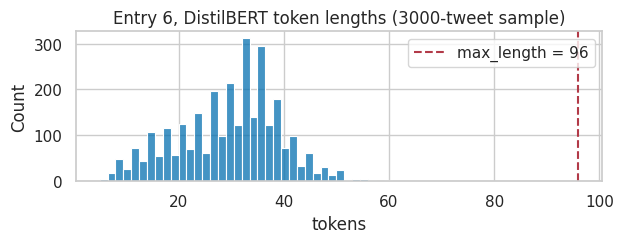

+----------------------------------------------+
| Entry 6, token lengths                       |
+----------------------------------------------+
| p50                                        31 |
| p90                                        40 |
| p95                                        44 |
| p99                                        50 |
| truncated_at_96_%                      0.0000 |
+----------------------------------------------+


In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(CFG["checkpoint"])

sample_texts = train_slice["message"].tolist()[:3000]
sub_lengths = np.array([len(tokenizer.encode(t, truncation=False)) for t in sample_texts])
truncated_pct = float((sub_lengths > CFG["max_length"]).mean() * 100)

plt.figure(figsize=(6.4, 2.6))
sns.histplot(sub_lengths, bins=40, color="#0570B0")
plt.axvline(CFG["max_length"], color="#b23a48", ls="--", label=f"max_length = {CFG['max_length']}")
plt.title("Entry 6, DistilBERT token lengths (3000-tweet sample)")
plt.xlabel("tokens")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES / "entry6_tokens.png", dpi=200, bbox_inches="tight")
plt.show()

scorecard("Entry 6, token lengths", {
    "p50": int(np.quantile(sub_lengths, 0.50)),
    "p90": int(np.quantile(sub_lengths, 0.90)),
    "p95": int(np.quantile(sub_lengths, 0.95)),
    "p99": int(np.quantile(sub_lengths, 0.99)),
    "truncated_at_96_%": round(truncated_pct, 2),
})

### **The one scorer I will reuse, then the classical baseline**

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

AVERAGING = CFG["averaging"]  # "macro", stated once, applied everywhere


def evaluate(y_true, y_pred) -> dict:
    """Shared scorer. Macro averaging so the minority classes are never masked by the majority."""
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average=AVERAGING, zero_division=0,
    )
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

classical = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_features=30_000, sublinear_tf=True)),
    ("clf", LogisticRegression(C=3.0, max_iter=1000, class_weight="balanced", n_jobs=-1)),
])
classical.fit(train_slice["message"], train_slice["target"])

classical_pred = classical.predict(test_slice["message"])
classical_scores = evaluate(test_slice["target"], classical_pred)
scorecard("Entry 7, TF-IDF + LogReg (test, macro)", classical_scores)

+----------------------------------------------+
| Entry 7, TF-IDF + LogReg (test, macro)       |
+----------------------------------------------+
| accuracy                               0.8065 |
| precision                              0.7458 |
| recall                                 0.7567 |
| f1                                     0.7508 |
+----------------------------------------------+


### **Tokenised datasets with dynamic padding**

In [ ]:
from datasets import Dataset
from transformers import DataCollatorWithPadding


def encode_slice(df: pd.DataFrame) -> Dataset:
    """Tokenise into an HF Dataset. No padding here, the collator handles it per batch."""
    ds = Dataset.from_pandas(
        df[["message", "target"]].reset_index(drop=True), preserve_index=False,
    )

    def _apply(batch):
        enc = tokenizer(batch["message"], truncation=True, max_length=CFG["max_length"])
        enc["labels"] = batch["target"]
        return enc

    wanted = ["input_ids", "attention_mask", "labels"]
    return ds.map(_apply, batched=True,
                  remove_columns=[c for c in ds.column_names if c not in wanted])


train_encoded = encode_slice(train_slice)
val_encoded = encode_slice(val_slice)
test_encoded = encode_slice(test_slice)

padder = DataCollatorWithPadding(tokenizer=tokenizer)
scorecard("Entry 8, encoded slices", {
    "train": len(train_encoded), "validation": len(val_encoded), "test": len(test_encoded),
})

Map:   0%|          | 0/10098 [00:00<?, ? examples/s]

Map:   0%|          | 0/2164 [00:00<?, ? examples/s]

Map:   0%|          | 0/2165 [00:00<?, ? examples/s]

+----------------------------------------------+
| Entry 8, encoded slices                      |
+----------------------------------------------+
| train                                   10098 |
| validation                               2164 |
| test                                     2165 |
+----------------------------------------------+


### **A weighted-loss Trainer to fight the negative skew**

In [ ]:
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments
import torch.nn as nn

# Inverse-frequency weights from TRAIN only (never test), normalised to mean 1.
train_counts = train_slice["target"].value_counts().reindex(range(N_CLASSES)).to_numpy()
inv_freq = train_counts.sum() / (N_CLASSES * train_counts)
CLASS_WEIGHTS = torch.tensor(inv_freq / inv_freq.mean(), dtype=torch.float, device=compute)
scorecard("Entry 9, class weights (from train)", {
    name: float(round(float(CLASS_WEIGHTS[ID_OF[name]]), 3)) for name in LABELS
})


class SkewAwareTrainer(Trainer):
    """Trainer whose loss up-weights the minority classes to counter the negative skew."""

    def __init__(self, *args, weights: torch.Tensor | None = None, **kwargs):
        super().__init__(*args, **kwargs)
        self._weights = weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss = nn.functional.cross_entropy(outputs.logits, labels, weight=self._weights)
        return (loss, outputs) if return_outputs else loss

+----------------------------------------------+
| Entry 9, class weights (from train)          |
+----------------------------------------------+
| negative                               0.3780 |
| neutral                                1.1230 |
| positive                               1.4990 |
+----------------------------------------------+


In [ ]:
def assemble_trainer(model, *, weighted: bool, tag: str) -> Trainer:
    """Build a SkewAwareTrainer. weighted=False drops the weighting for the Entry 11 ablation."""
    args = TrainingArguments(
        output_dir=str(CHECKPOINTS / tag),
        num_train_epochs=CFG["epochs"],                      # 3 epochs adapt a small model on ~10k tweets
        per_device_train_batch_size=CFG["batch_size"],       # 32 fits given short, dynamically padded inputs
        per_device_eval_batch_size=CFG["batch_size"] * 2,    # eval has no backward pass, so double it
        learning_rate=CFG["learning_rate"],                  # 2e-5 is the stable BERT fine-tuning rate
        weight_decay=CFG["weight_decay"],                    # light L2 on the AdamW updates
        warmup_ratio=CFG["warmup_ratio"],                    # linear warmup avoids a first-step shock
        eval_strategy="epoch",                               # validate each epoch to drive selection
        save_strategy="epoch",                               # checkpoint each epoch so the best reloads
        load_best_model_at_end=True,                         # enforce the Entry 10 selection rule
        metric_for_best_model="f1",                          # macro-F1 (below) picks the winning epoch
        greater_is_better=True,
        save_total_limit=1,                                  # keep only the best checkpoint (Colab disk)
        seed=RUN_SEED,                                       # reproducible shuffling and init
        report_to="none",                                    # no external loggers on Colab
        logging_steps=50,
        fp16=torch.cuda.is_available(),                      # mixed precision on GPU for a free speed-up
    )

    def hf_compute_metrics(eval_pred):
        logits, labels = eval_pred
        return evaluate(labels, np.argmax(logits, axis=-1))  # reuse the one shared scorer

    return SkewAwareTrainer(
        model=model,
        args=args,
        train_dataset=train_encoded,
        eval_dataset=val_encoded,
        data_collator=padder,
        compute_metrics=hf_compute_metrics,
        weights=CLASS_WEIGHTS if weighted else None,
    )

### **Fine-tuning, then choosing the checkpoint on purpose**

In [ ]:
main_model = AutoModelForSequenceClassification.from_pretrained(
    CFG["checkpoint"], num_labels=N_CLASSES, id2label=NAME_OF, label2id=ID_OF,
).to(compute)

main_trainer = assemble_trainer(main_model, weighted=CFG["class_weighted"], tag="weighted_main")

_clock = time.time()
main_trainer.train()
train_minutes = (time.time() - _clock) / 60
scorecard("Entry 10, training done", {"minutes": float(round(train_minutes, 2))})

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.545200,0.528140,0.805453,0.741987,0.788390,0.760178
2,0.441300,0.528016,0.819316,0.769200,0.794445,0.780346
3,0.309100,0.555197,0.827172,0.778815,0.799352,0.788367


+----------------------------------------------+
| Entry 10, training done                      |
+----------------------------------------------+
| minutes                                1.4500 |
+----------------------------------------------+


In [ ]:
val_history = pd.DataFrame(
    [h for h in main_trainer.state.log_history if "eval_f1" in h]
)[["epoch", "eval_accuracy", "eval_precision", "eval_recall", "eval_f1"]].round(4)
print("validation history (macro):")
print(val_history.to_string(index=False))

selected = CHECKPOINTS / "best_weighted"
main_trainer.save_model(str(selected))
tokenizer.save_pretrained(str(selected))
scorecard("Entry 10, selected checkpoint", {
    "rule": "max val macro-F1",
    "best_val_f1": float(main_trainer.state.best_metric),
    "saved_to": str(selected),
})

validation history (macro):
 epoch  eval_accuracy  eval_precision  eval_recall  eval_f1
   1.0         0.8055          0.7420       0.7884   0.7602
   2.0         0.8193          0.7692       0.7944   0.7803
   3.0         0.8272          0.7788       0.7994   0.7884
+----------------------------------------------+
| Entry 10, selected checkpoint                |
+----------------------------------------------+
| rule                         max val macro-F1 |
| best_val_f1                            0.7884 |
| saved_to                outputs/models/best_weighted |
+----------------------------------------------+


### **The single test pass**

In [ ]:
test_out = main_trainer.predict(test_encoded)
test_gold = test_out.label_ids
test_pred = np.argmax(test_out.predictions, axis=-1)

transformer_scores = evaluate(test_gold, test_pred)
scorecard("Entry 11, DistilBERT (test, macro)", transformer_scores)

+----------------------------------------------+
| Entry 11, DistilBERT (test, macro)           |
+----------------------------------------------+
| accuracy                               0.8365 |
| precision                              0.7832 |
| recall                                 0.8095 |
| f1                                     0.7952 |
+----------------------------------------------+


### **Baseline versus transformer, on the same ruler**

In [ ]:
comparison = pd.DataFrame(
    {"TF-IDF + LogReg": classical_scores, "DistilBERT (weighted)": transformer_scores}
).T.round(4)
comparison.to_csv(TABLES / "model_comparison.csv")
for model_name, row in comparison.iterrows():
    scorecard(f"Entry 12, {model_name}", row.to_dict())

+----------------------------------------------+
| Entry 12, TF-IDF + LogReg                    |
+----------------------------------------------+
| accuracy                               0.8065 |
| precision                              0.7458 |
| recall                                 0.7567 |
| f1                                     0.7508 |
+----------------------------------------------+
+----------------------------------------------+
| Entry 12, DistilBERT (weighted)              |
+----------------------------------------------+
| accuracy                               0.8365 |
| precision                              0.7832 |
| recall                                 0.8095 |
| f1                                     0.7952 |
+----------------------------------------------+


              precision    recall  f1-score   support

    negative     0.9242    0.8774    0.9002      1362
     neutral     0.6660    0.7168    0.6905       459
    positive     0.7593    0.8343    0.7950       344

    accuracy                         0.8365      2165
   macro avg     0.7832    0.8095    0.7952      2165
weighted avg     0.8433    0.8365    0.8390      2165



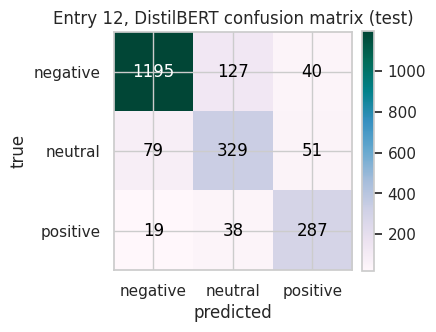

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

conf = confusion_matrix(test_gold, test_pred)
print(classification_report(test_gold, test_pred, target_names=list(LABELS), digits=4))

fig, ax = plt.subplots(figsize=(4.4, 3.9))
im = ax.imshow(conf, cmap="PuBuGn")
ax.set_xticks(range(N_CLASSES)); ax.set_yticks(range(N_CLASSES))
ax.set_xticklabels(LABELS); ax.set_yticklabels(LABELS)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title("Entry 12, DistilBERT confusion matrix (test)")
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        ax.text(j, i, int(conf[i, j]), ha="center", va="center",
                color="white" if conf[i, j] > conf.max() / 2 else "black")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(FIGURES / "entry12_confusion.png", dpi=200, bbox_inches="tight")
plt.show()

### **Chasing my specific error hypothesis**

In [ ]:
neu, neg = ID_OF["neutral"], ID_OF["negative"]
neutral_total = int(conf[neu].sum())
neutral_to_negative = int(conf[neu, neg])
neutral_recall = conf[neu, neu] / max(neutral_total, 1)

scorecard("Entry 13, the neutral->negative leak", {
    "neutral_in_test": neutral_total,
    "neutral_as_negative": neutral_to_negative,
    "leak_share_of_neutral": float(neutral_to_negative / max(neutral_total, 1)),
    "neutral_recall": float(neutral_recall),
})

inspect = test_slice.reset_index(drop=True).copy()
inspect["pred"] = test_pred
leaked = inspect[(inspect["target"] == neu) & (inspect["pred"] == neg)]
print(f"\nsample neutral tweets misread as negative ({len(leaked)} total):")
for _, r in leaked.head(8).iterrows():
    print("  -", r["message"][:140])

+----------------------------------------------+
| Entry 13, the neutral->negative leak         |
+----------------------------------------------+
| neutral_in_test                           459 |
| neutral_as_negative                        79 |
| leak_share_of_neutral                  0.1721 |
| neutral_recall                         0.7168 |
+----------------------------------------------+

sample neutral tweets misread as negative (79 total):
  - @united just kidding with you I'll send you my stuff now. Thanks
  - @USAirways a $75 change is ok most of the time but if there r open seats on earlier flt and no chkd bag, why not let someone fly standby?
  - @AmericanAir but my friend was told she was able to use her credit with the airline towards one of my flights, then was told she couldn't.
  - @VirginAmerica, @reallytallchris dropped a track on you... https://t.co/zv2pt6TRK9
  - @united so if this game was the one reason I payed for @DIRECTV is there something we could work out her

### **Does the class weighting actually earn its place?**

In [ ]:
lock_seeds(RUN_SEED)  # reset so the only thing that changes is the loss weighting
plain_model = AutoModelForSequenceClassification.from_pretrained(
    CFG["checkpoint"], num_labels=N_CLASSES, id2label=NAME_OF, label2id=ID_OF,
).to(compute)

plain_trainer = assemble_trainer(plain_model, weighted=False, tag="unweighted_ablation")
plain_trainer.train()

plain_out = plain_trainer.predict(test_encoded)
plain_pred = np.argmax(plain_out.predictions, axis=-1)
plain_scores = evaluate(plain_out.label_ids, plain_pred)

plain_conf = confusion_matrix(plain_out.label_ids, plain_pred)
per_class_recall = []
for name in LABELS:
    k = ID_OF[name]
    per_class_recall.append({
        "class": name,
        "recall_unweighted": round(plain_conf[k, k] / max(plain_conf[k].sum(), 1), 4),
        "recall_weighted": round(conf[k, k] / max(conf[k].sum(), 1), 4),
    })

ablation = pd.DataFrame(
    {"unweighted loss": plain_scores, "weighted loss (main)": transformer_scores}
).T.round(4)
ablation.to_csv(TABLES / "class_weight_ablation.csv")
for row_name, row in ablation.iterrows():
    scorecard(f"Entry 14, {row_name}", row.to_dict())
print("\nper-class recall (unweighted vs weighted):")
print(pd.DataFrame(per_class_recall).to_string(index=False))

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.473400,0.451512,0.822089,0.783559,0.744858,0.755852
2,0.372900,0.448904,0.833641,0.807215,0.753522,0.775776
3,0.259800,0.458666,0.835490,0.798022,0.775990,0.786138


+----------------------------------------------+
| Entry 14, unweighted loss                    |
+----------------------------------------------+
| accuracy                               0.8393 |
| precision                              0.7954 |
| recall                                 0.7818 |
| f1                                     0.7873 |
+----------------------------------------------+
+----------------------------------------------+
| Entry 14, weighted loss (main)               |
+----------------------------------------------+
| accuracy                               0.8365 |
| precision                              0.7832 |
| recall                                 0.8095 |
| f1                                     0.7952 |
+----------------------------------------------+

per-class recall (unweighted vs weighted):
   class  recall_unweighted  recall_weighted
negative             0.9229           0.8774
 neutral             0.6144           0.7168
positive             0.8081  